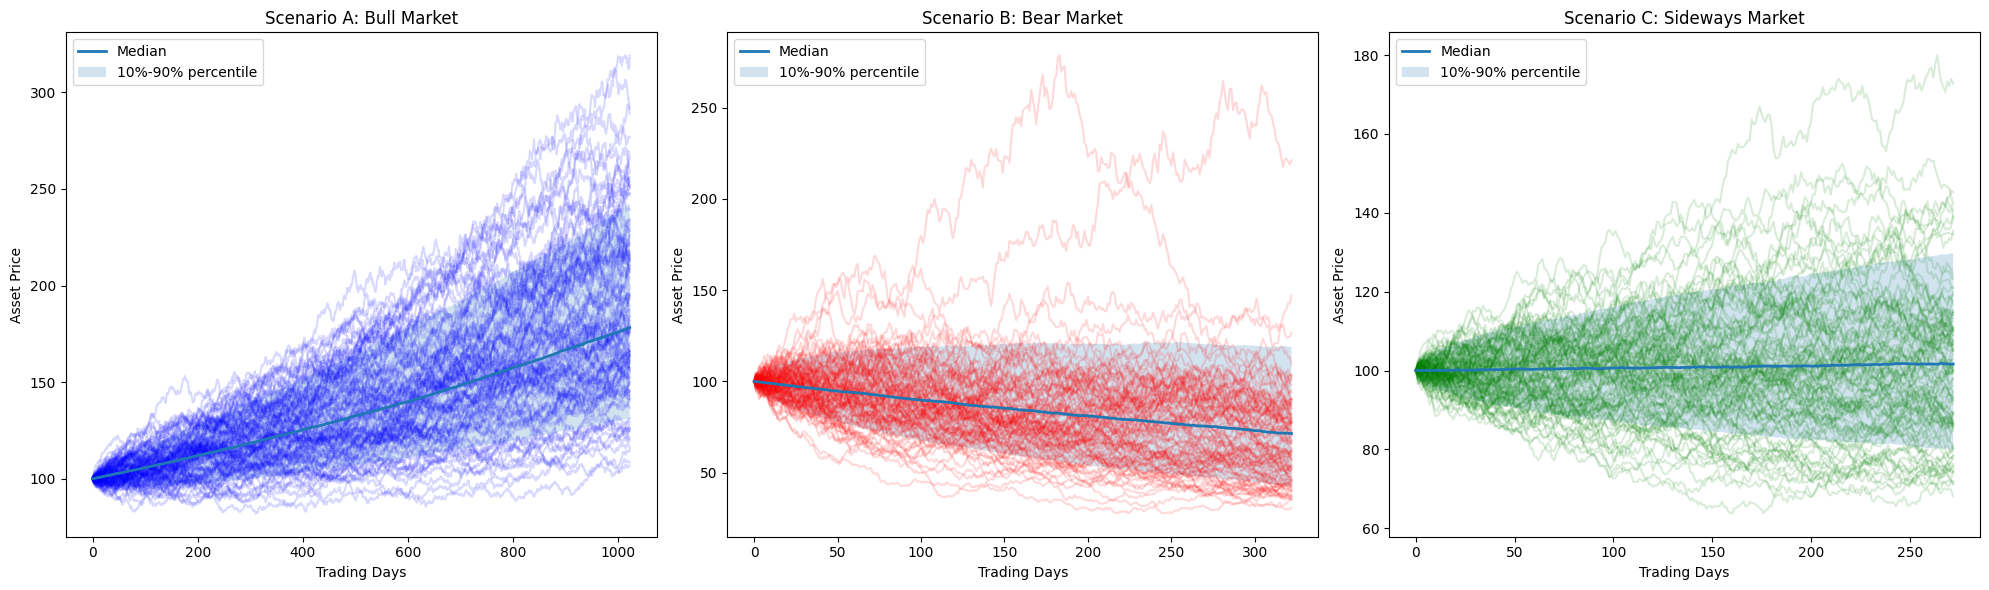


BULL MARKET
----------------------------------------
Mean final price:     183.44
Median final price:   178.30
Min final price:      71.46
Max final price:      468.37
10th percentile:      131.27
90th percentile:      242.56

BEAR MARKET
----------------------------------------
Mean final price:     77.45
Median final price:   71.47
Min final price:      17.73
Max final price:      307.24
10th percentile:      42.79
90th percentile:      118.84

SIDEWAYS MARKET
----------------------------------------
Mean final price:     103.58
Median final price:   101.65
Min final price:      51.83
Max final price:      191.27
10th percentile:      80.13
90th percentile:      129.67


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)


# ============================================================
# FUNKCJA SYMULUJĄCA GEOMETRIC BROWNIAN MOTION
# ============================================================
def run_monte_carlo(S0, mu, sigma, days, num_paths):

    """
    PARAMETRY:
    --------------------------------------------------------
    S0        : cena początkowa aktywa
    mu        : roczny dryf (expected return)
    sigma     : roczna zmienność
    days      : liczba dni sesyjnych
    num_paths : liczba ścieżek Monte Carlo

    ZWRACA:
    --------------------------------------------------------
    prices : macierz cen:
             wiersze -> kolejne dni
             kolumny -> kolejne ścieżki
    """

    # ========================================================
    # KROK CZASOWY
    # ========================================================
    # Zakładamy 252 sesje giełdowe w roku.
    dt = 1 / 252

    # ========================================================
    # GENEROWANIE LOSOWYCH SZOKÓW
    # ========================================================
    # Każde Z ~ N(0,1)
    # Tworzymy macierz:
    #   liczba dni  x  liczba ścieżek
    shocks = np.random.normal(
        loc=0,
        scale=1,
        size=(days, num_paths)
    )

    # ========================================================
    # DYSKRETNY MODEL GBM
    # ========================================================
    # Model:
    #
    # S(t+dt) = S(t) * exp(
    #   (mu - 0.5*sigma^2)*dt
    #   + sigma*sqrt(dt)*Z
    # )
    #
    # gdzie:
    #   mu      -> średni zwrot
    #   sigma   -> zmienność
    #   Z       -> losowy szok normalny
    #
    returns = np.exp(
        (mu - 0.5 * sigma**2) * dt
        + sigma * np.sqrt(dt) * shocks
    )

    # ========================================================
    # INICJALIZACJA MACIERZY CEN
    # ========================================================
    # +1 ponieważ dodajemy dzień początkowy.
    prices = np.zeros((days + 1, num_paths))

    # Wszystkie ścieżki startują od tej samej ceny.
    prices[0] = S0

    # ========================================================
    # KUMULACJA ZWROTÓW
    # ========================================================
    # np.cumprod liczy iloczyn skumulowany:
    #
    # dzień 1 -> r1
    # dzień 2 -> r1*r2
    # dzień 3 -> r1*r2*r3
    #
    prices[1:] = S0 * np.cumprod(returns, axis=0)

    return prices


# ============================================================
# STEP 3 — PARAMETRY SYMULACJI
# ============================================================

S0 = 100
paths = 10000

# ------------------------------------------------------------
# SCENARIUSZ A — BULL MARKET
# ------------------------------------------------------------
bull = run_monte_carlo(
    S0=S0,
    mu=0.15,       # 15% rocznie
    sigma=0.12,    # 12% volatility
    days=1022,
    num_paths=paths
)

# ------------------------------------------------------------
# SCENARIUSZ B — BEAR MARKET
# ------------------------------------------------------------
bear = run_monte_carlo(
    S0=S0,
    mu=-0.20,      # -20% rocznie
    sigma=0.35,    # wysoka zmienność
    days=322,
    num_paths=paths
)

# ------------------------------------------------------------
# SCENARIUSZ C — SIDEWAYS MARKET
# ------------------------------------------------------------
side = run_monte_carlo(
    S0=S0,
    mu=0.03,       # lekko dodatni dryf
    sigma=0.18,
    days=272,
    num_paths=paths
)


# ============================================================
# STEP 4 — FUNKCJA RYSUJĄCA WYNIKI
# ============================================================
def plot_scenario(ax, data, title, color):

    # --------------------------------------------------------
    # RYSUJEMY LOSOWE ŚCIEŻKI
    # --------------------------------------------------------
    # Pokazujemy tylko 100 dla czytelności.
    ax.plot(
        data[:, :100],
        color=color,
        alpha=0.15
    )

    # --------------------------------------------------------
    # MEDIANA
    # --------------------------------------------------------
    median = np.median(data, axis=1)

    # --------------------------------------------------------
    # PERCENTYLE
    # --------------------------------------------------------
    p10 = np.percentile(data, 10, axis=1)
    p90 = np.percentile(data, 90, axis=1)

    # --------------------------------------------------------
    # RYSOWANIE MEDIANY
    # --------------------------------------------------------
    ax.plot(
        median,
        linewidth=2,
        label='Median'
    )

    # --------------------------------------------------------
    # PRZEDZIAŁ UFNOŚCI
    # --------------------------------------------------------
    ax.fill_between(
        range(len(median)),
        p10,
        p90,
        alpha=0.2,
        label='10%-90% percentile'
    )

    # --------------------------------------------------------
    # OPISY
    # --------------------------------------------------------
    ax.set_title(title)
    ax.set_xlabel("Trading Days")
    ax.set_ylabel("Asset Price")
    ax.legend()


# ============================================================
# STEP 5 — TWORZENIE WYKRESÓW
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

plot_scenario(
    axes[0],
    bull,
    "Scenario A: Bull Market",
    "blue"
)

plot_scenario(
    axes[1],
    bear,
    "Scenario B: Bear Market",
    "red"
)

plot_scenario(
    axes[2],
    side,
    "Scenario C: Sideways Market",
    "green"
)

plt.tight_layout()
plt.show()


# ============================================================
# STEP 6 — ANALIZA KOŃCOWYCH WYNIKÓW
# ============================================================

def summarize_results(data, name):

    final_prices = data[-1]

    print(f"\n{name}")
    print("-" * 40)

    print(f"Mean final price:     {np.mean(final_prices):.2f}")
    print(f"Median final price:   {np.median(final_prices):.2f}")
    print(f"Min final price:      {np.min(final_prices):.2f}")
    print(f"Max final price:      {np.max(final_prices):.2f}")

    print(f"10th percentile:      {np.percentile(final_prices, 10):.2f}")
    print(f"90th percentile:      {np.percentile(final_prices, 90):.2f}")


summarize_results(bull, "BULL MARKET")
summarize_results(bear, "BEAR MARKET")
summarize_results(side, "SIDEWAYS MARKET")

Symuluję Bull Market (10000 ścieżek)...
Symuluję Bear Market (10000 ścieżek)...
Symuluję Sideways Market (10000 ścieżek)...

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Bull Market
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Metryka                                Wheel      Buy&Hold
──────────────────────────────────────────────────────────────
Średnia końcowa [$]                  152,913       181,068
Mediana końcowa [$]                  154,940       175,899
Odch. std [$]                         15,397        43,698
CAGR                                  11.04%        15.77%
P(strata)                              0.43%         0.93%
CVaR 95%                              14.54%         8.08%
Avg Max Drawdown                     -10.10%       -13.99%
Sharpe Ratio (ann.)                   1.1833        0.7369
Sortino Ratio (ann.)                  1.4321        2.3347
P(Wheel > B&H)                        21.87% –
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

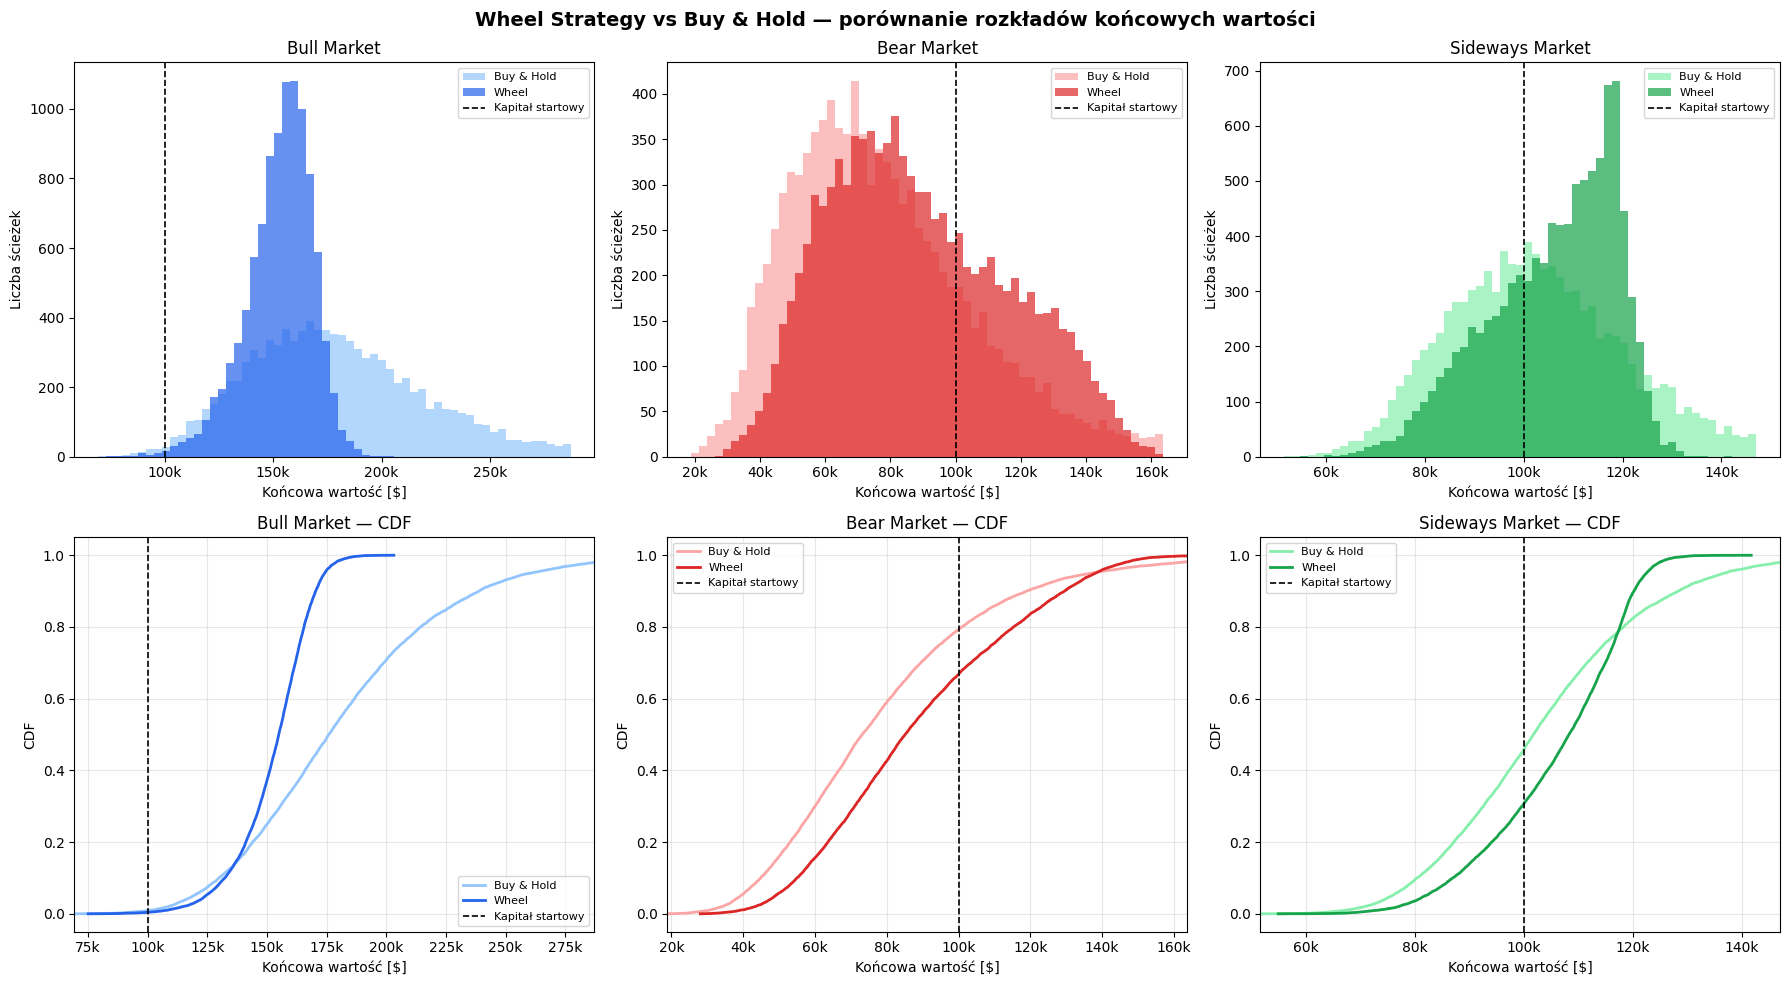


Wykres zapisany: wheel_vs_bh.png


In [ ]:
# -*- coding: utf-8 -*-
"""
WHEEL STRATEGY vs BUY & HOLD — porównanie na Monte Carlo
=========================================================
Oba portfele startują w dniu 22 z kapitałem 100 000 USD.
Buy & Hold: kupuje akcje w dniu 22 i trzyma do końca.
Wheel:      wystawia opcje PUT/CALL zgodnie z algorytmem.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import norm

np.random.seed(42)

INITIAL_CAPITAL = 100_000
START_DAY       = 22
R               = 0.04      # stopa wolna od ryzyka (roczna)
CONTRACT_SIZE   = 100       # akcji na 1 kontrakt opcyjny
TARGET_DELTA    = 0.30
OPTION_DAYS     = 21
NUM_PATHS       = 10_000


# ─────────────────────────────────────────────────────────────
# BLOK 1 — GEOMETRIC BROWNIAN MOTION
# ─────────────────────────────────────────────────────────────

def run_monte_carlo(S0, mu, sigma, days, num_paths):
    dt      = 1 / 252
    shocks  = np.random.normal(0, 1, (days, num_paths))
    returns = np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * shocks)
    prices  = np.zeros((days + 1, num_paths))
    prices[0] = S0
    prices[1:] = S0 * np.cumprod(returns, axis=0)
    return prices


# ─────────────────────────────────────────────────────────────
# BLOK 2 — BLACK-SCHOLES
# ─────────────────────────────────────────────────────────────

def bs_price(S, K, T, r, sigma, option="put"):
    if T <= 0:
        return max(0.0, (K - S) if option == "put" else (S - K))
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option == "put":
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def find_strike(S, T, r, sigma, target_delta, option="put"):
    """Analityczne odwrócenie BS: wyznacza K dla zadanej |delty|."""
    delta_call = (1 - target_delta) if option == "put" else target_delta
    d1 = norm.ppf(delta_call)
    return S * np.exp(-d1 * sigma * np.sqrt(T) + (r + 0.5 * sigma**2) * T)


# ─────────────────────────────────────────────────────────────
# BLOK 3 — ZMIENNOŚĆ IMPLIKOWANA (krocząca 21-dniowa + 2% VRP)
# ─────────────────────────────────────────────────────────────

def calculate_iv(prices):
    """
    Krocząca 21-dniowa zmienność zrealizowana + 2% (volatility risk premium).
    Zwraca tablicę IV o tej samej długości co prices.
    Pierwsze 21 wartości = 0 (brak historii) — agent startuje w dniu 22, więc OK.
    """
    rets = np.log(prices[1:] / prices[:-1])
    iv   = np.zeros_like(prices)
    for t in range(21, len(prices)):
        realized_vol = np.std(rets[t-21:t], ddof=1) * np.sqrt(252)
        iv[t]        = realized_vol + 0.02        # +2% VRP
    return iv


# ─────────────────────────────────────────────────────────────
# BLOK 4 — BUY & HOLD
# ─────────────────────────────────────────────────────────────

def simulate_bh(price_path, start_day=START_DAY, initial=INITIAL_CAPITAL):
    """
    Kupuje akcje w start_day za cały kapitał.
    Zwraca: (historia dzienna wartości, końcowa wartość)
    """
    S_buy  = price_path[start_day]
    shares = initial / S_buy
    values = shares * price_path[start_day:]
    return values, float(values[-1])


# ─────────────────────────────────────────────────────────────
# BLOK 5 — WHEEL STRATEGY
# ─────────────────────────────────────────────────────────────

def simulate_wheel(price_path, iv_path, r=R, target_delta=TARGET_DELTA,
                   option_days=OPTION_DAYS, start_day=START_DAY,
                   contract_size=CONTRACT_SIZE, initial=INITIAL_CAPITAL):
    cash       = float(initial)
    shares     = 0
    K_assigned = None
    state      = "PUT"
    day        = start_day
    total_days = len(price_path) - 1
    T_exp      = option_days / 252
    history    = []

    while day <= total_days:
        S     = price_path[day]
        sigma = iv_path[day]

        if state == "PUT":
            K           = find_strike(S, T_exp, r, sigma, target_delta, "put")
            n_contracts = int(cash / (K * contract_size))

            if n_contracts <= 0:
                # Brak kapitału na kolejny kontrakt — kończymy handel, trzymamy gotówkę
                for d in range(day, total_days + 1):
                    history.append(cash + shares * price_path[d])
                break

            premium  = bs_price(S, K, T_exp, r, sigma, "put") * contract_size * n_contracts
            cash    += premium

        else:  # state == "CALL"
            K_delta     = find_strike(S, T_exp, r, sigma, target_delta, "call")
            K           = max(K_assigned, K_delta)
            n_contracts = int(shares // contract_size)

            if n_contracts <= 0:
                # POPRAWKA: zamiast continue (ryzyko pętli nieskończonej),
                # od razu przechodzimy do wystawienia PUT na tym samym dniu.
                state = "PUT"
                K           = find_strike(S, T_exp, r, sigma, target_delta, "put")
                n_contracts = int(cash / (K * contract_size))
                if n_contracts <= 0:
                    for d in range(day, total_days + 1):
                        history.append(cash + shares * price_path[d])
                    break
                premium  = bs_price(S, K, T_exp, r, sigma, "put") * contract_size * n_contracts
                cash    += premium

            else:
                premium  = bs_price(S, K, T_exp, r, sigma, "call") * contract_size * n_contracts
                cash    += premium

        expiry_day = min(day + option_days, total_days)

        for d in range(day, expiry_day + 1):
            cash *= np.exp(r / 252)
            history.append(cash + shares * price_path[d])

        S_exp = price_path[expiry_day]
        if state == "PUT":
            if S_exp < K:
                cash      -= K * contract_size * n_contracts
                shares    += contract_size * n_contracts
                K_assigned = K
                state      = "CALL"
        else:
            if S_exp > K:
                cash      += K * contract_size * n_contracts
                shares    -= contract_size * n_contracts
                K_assigned = None
                state      = "PUT"

        day = expiry_day + 1

    final = history[-1] if history else float(initial)
    return np.array(history), final


# ─────────────────────────────────────────────────────────────
# BLOK 6 — METRYKI
#
# POPRAWKI:
#   1. Maximum Drawdown: liczony po osi czasu na każdej ścieżce
#      osobno, a następnie uśredniany — zamiast błędnego
#      przybliżenia cross-sectional.
#      Wymaga przekazania histories (lista tablic history[]).
#
#   2. Sharpe Ratio: annualizowany przez podzielenie przez sqrt(years),
#      mianownik to excess.std() (nie returns.std()).
# ─────────────────────────────────────────────────────────────

def max_drawdown_single(history):
    """MDD dla jednej ścieżki czasowej wartości portfela."""
    arr         = np.array(history)
    peak        = np.maximum.accumulate(arr)
    drawdowns   = (arr - peak) / peak
    return drawdowns.min()


def compute_metrics(final_values, histories, years,
                    initial=INITIAL_CAPITAL, rf_annual=R):
    """
    Parametry:
        final_values : tablica końcowych wartości portfela (jedna liczba / ścieżka)
        histories    : lista tablic history[] — pełna historia każdej ścieżki
        years        : długość horyzontu w latach
        initial      : kapitał startowy
        rf_annual    : roczna stopa wolna od ryzyka
    """
    fv      = np.array(final_values)
    returns = (fv / initial) - 1           # całkowity zwrot każdej ścieżki
    rf      = rf_annual * years            # benchmark za cały okres

    excess  = returns - rf

    # --- Sharpe annualizowany -------------------------------------------
    # Dzielimy przez sqrt(years), żeby sprowadzić do skali rocznej.
    sharpe = (excess.mean() / (excess.std(ddof=1) + 1e-9)) / np.sqrt(years)

    # --- Sortino annualizowany ------------------------------------------
    downside     = returns[returns < rf] - rf
    downside_std = np.sqrt((downside**2).mean()) if len(downside) > 0 else 1e-9
    sortino      = (excess.mean() / (downside_std + 1e-9)) / np.sqrt(years)

    # --- Maximum Drawdown -----------------------------------------------
    # Liczymy MDD dla każdej ścieżki osobno i uśredniamy.
    mdd_values = np.array([max_drawdown_single(h) for h in histories])
    mdd        = mdd_values.mean()

    # --- CVaR 95% --------------------------------------------------------
    threshold = np.percentile(returns, 5)
    cvar_95   = returns[returns <= threshold].mean()

    return {
        "mean":    fv.mean(),
        "median":  np.median(fv),
        "std":     fv.std(ddof=1),
        "cagr":    (fv.mean() / initial) ** (1 / years) - 1,
        "p_loss":  (fv < initial).mean(),
        "cvar_95": cvar_95,
        "mdd":     mdd,
        "sharpe":  sharpe,
        "sortino": sortino,
    }


def print_comparison(name, m_wheel, m_bh, fv_wheel, fv_bh):
    """Drukuje tabelę porównawczą dla jednego scenariusza."""
    p_beat = (np.array(fv_wheel) > np.array(fv_bh)).mean()

    print(f"\n{'━'*62}")
    print(f"  {name}")
    print(f"{'━'*62}")
    print(f"{'Metryka':<30} {'Wheel':>13} {'Buy&Hold':>13}")
    print(f"{'─'*62}")

    rows = [
        ("Średnia końcowa [$]",
            f"{m_wheel['mean']:>13,.0f}", f"{m_bh['mean']:>13,.0f}"),
        ("Mediana końcowa [$]",
            f"{m_wheel['median']:>13,.0f}", f"{m_bh['median']:>13,.0f}"),
        ("Odch. std [$]",
            f"{m_wheel['std']:>13,.0f}", f"{m_bh['std']:>13,.0f}"),
        ("CAGR",
            f"{m_wheel['cagr']*100:>12.2f}%", f"{m_bh['cagr']*100:>12.2f}%"),
        ("P(strata)",
            f"{m_wheel['p_loss']*100:>12.2f}%", f"{m_bh['p_loss']*100:>12.2f}%"),
        ("CVaR 95%",
            f"{m_wheel['cvar_95']*100:>12.2f}%", f"{m_bh['cvar_95']*100:>12.2f}%"),
        ("Avg Max Drawdown",
            f"{m_wheel['mdd']*100:>12.2f}%", f"{m_bh['mdd']*100:>12.2f}%"),
        ("Sharpe Ratio (ann.)",
            f"{m_wheel['sharpe']:>13.4f}", f"{m_bh['sharpe']:>13.4f}"),
        ("Sortino Ratio (ann.)",
            f"{m_wheel['sortino']:>13.4f}", f"{m_bh['sortino']:>13.4f}"),
        ("P(Wheel > B&H)",
            f"{p_beat*100:>12.2f}%", "–"),
    ]
    for label, w, b in rows:
        print(f"{label:<30} {w} {b}")
    print(f"{'━'*62}")


# ─────────────────────────────────────────────────────────────
# BLOK 7 — URUCHOMIENIE SYMULACJI
# POPRAWKA: zbieramy teraz histories_wheel i histories_bh
#           (listy pełnych historii) potrzebne do poprawnego MDD.
# ─────────────────────────────────────────────────────────────

S0        = 100
scenarios = {
    "Bull Market":     dict(mu=0.15,  sigma=0.12, days=1022),
    "Bear Market":     dict(mu=-0.20, sigma=0.35, days=322),
    "Sideways Market": dict(mu=0.03,  sigma=0.18, days=272),
}

wheel_results    = {}
bh_results       = {}
wheel_histories  = {}
bh_histories     = {}

for name, p in scenarios.items():
    print(f"Symuluję {name} ({NUM_PATHS} ścieżek)...")
    prices = run_monte_carlo(S0, p["mu"], p["sigma"], p["days"], NUM_PATHS)

    fv_wheel, fv_bh   = [], []
    hist_wheel, hist_bh = [], []

    for i in range(NUM_PATHS):
        iv = calculate_iv(prices[:, i])

        h_w, wv = simulate_wheel(prices[:, i], iv_path=iv)
        h_b, bv = simulate_bh(prices[:, i])

        fv_wheel.append(wv);   hist_wheel.append(h_w)
        fv_bh.append(bv);      hist_bh.append(h_b)

    wheel_results[name]   = np.array(fv_wheel)
    bh_results[name]      = np.array(fv_bh)
    wheel_histories[name] = hist_wheel
    bh_histories[name]    = hist_bh

years_map = {k: v["days"] / 252 for k, v in scenarios.items()}


# ─────────────────────────────────────────────────────────────
# BLOK 8 — TABELE PORÓWNAWCZE
# ─────────────────────────────────────────────────────────────

for name in scenarios:
    y    = years_map[name]
    m_w  = compute_metrics(wheel_results[name],  wheel_histories[name],  y)
    m_bh = compute_metrics(bh_results[name],     bh_histories[name],     y)
    print_comparison(name, m_w, m_bh, wheel_results[name], bh_results[name])


# ─────────────────────────────────────────────────────────────
# BLOK 9 — WYKRESY: histogramy + CDF
# POPRAWKA: przycinamy oś X do 99. percentyla, żeby bull market
#           z długim prawym ogonem B&H nie spłaszczał histogramu Wheel.
# ─────────────────────────────────────────────────────────────

colors = {
    "Bull Market":     ("#2563EB", "#93C5FD"),
    "Bear Market":     ("#DC2626", "#FCA5A5"),
    "Sideways Market": ("#16A34A", "#86EFAC"),
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    "Wheel Strategy vs Buy & Hold — porównanie rozkładów końcowych wartości",
    fontsize=14, fontweight="bold"
)

for col, name in enumerate(scenarios):
    fv_w  = wheel_results[name]
    fv_bh = bh_results[name]
    c_dark, c_light = colors[name]

    # Wspólny zakres osi: od minimum do 99. percentyla (usuwa ekstremalne wartości)
    x_min = min(fv_w.min(), fv_bh.min())
    x_max = np.percentile(np.concatenate([fv_w, fv_bh]), 99)
    bins  = np.linspace(x_min, x_max, 60)

    # ── Wiersz 1: histogramy ─────────────────────────────────
    ax = axes[0, col]
    ax.hist(fv_bh, bins=bins, color=c_light, alpha=0.7, label="Buy & Hold")
    ax.hist(fv_w,  bins=bins, color=c_dark,  alpha=0.7, label="Wheel")
    ax.axvline(INITIAL_CAPITAL, color="black", linestyle="--",
               linewidth=1.2, label="Kapitał startowy")
    ax.set_title(name)
    ax.set_xlabel("Końcowa wartość [$]")
    ax.set_ylabel("Liczba ścieżek")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{x/1_000:.0f}k"))
    ax.legend(fontsize=8)

    # ── Wiersz 2: dystrybuanty (CDF) ─────────────────────────
    ax2 = axes[1, col]
    for fv, label, color in [(fv_bh, "Buy & Hold", c_light),
                              (fv_w,  "Wheel",      c_dark)]:
        sorted_fv = np.sort(fv)
        cdf       = np.arange(1, len(fv) + 1) / len(fv)
        ax2.plot(sorted_fv, cdf, color=color, linewidth=2, label=label)
    ax2.axvline(INITIAL_CAPITAL, color="black", linestyle="--",
                linewidth=1.2, label="Kapitał startowy")
    ax2.set_xlim(x_min, x_max)
    ax2.set_xlabel("Końcowa wartość [$]")
    ax2.set_ylabel("CDF")
    ax2.set_title(f"{name} — CDF")
    ax2.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{x/1_000:.0f}k"))
    ax2.legend(fontsize=8)
    ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("wheel_vs_bh.png", dpi=150)
plt.show()
print("\nWykres zapisany: wheel_vs_bh.png")